# Week 1 Data Quality, Returns, and Portfolio Analysis

**Project:** Lendo Quant Research Internship — Week 1  
**Dataset:** Yahoo Finance OHLCV for 100 current S&P 500 constituents  
**Frequency:** Daily trading observations  
**Adjusted price field:** `adj_close`

This notebook integrates Tasks 2–5 into the final Week 1 deliverable. It loads the raw dataset, validates schema and trading-calendar coverage, documents and applies cleaning rules, computes simple/log returns at daily/weekly/monthly frequencies, and compares equal-weight and value-weight 50-stock portfolios.

## Reproducibility assumptions

- The S&P 500 universe is a **current constituent snapshot**, not point-in-time index membership. This creates survivorship-bias risk.
- Yahoo Finance `adj_close` already adjusts for splits and dividends; no additional split adjustment is applied.
- Suspicious observations are flagged and reviewed rather than silently removed.
- Annualization uses **252 trading days**. Sharpe ratios use a **0% annual risk-free rate** unless stated otherwise.
- The value-weight portfolio uses the first 252 trading days of average dollar volume (`adj_close × volume`) as a **liquidity-value proxy**, because true historical market-cap weights are not available in this dataset.

## 1. Environment and project path setup

The notebook can be executed either from the repository root or from `notebooks/week1/`. The first cell walks upward until it finds the `src/` package.

In [ ]:
from pathlib import Path
import json
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy import stats
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "src").exists():
    raise FileNotFoundError("Could not locate the project src/ directory")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from src.data_utils import (
    NUMERIC_OHLCV_COLUMNS,
    average_daily_volume,
    annualized_volatility,
    clean_ohlcv,
    compute_returns,
    compute_rolling_stats,
    cumulative_returns,
    load_ohlcv,
    pivot_ohlcv,
    portfolio_performance,
    portfolio_returns,
    summarize_ohlcv,
    validate_ohlcv,
)
DATA_PATH = Path(r"C:\Users\dwt04\Desktop\北美求职\LENDO\dataset\sp500_100_10y_ohlcv.csv")

#METADATA_PATH = PROJECT_ROOT / "data" / "raw" / "sp500_100_10y_metadata.json"

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid", context="notebook")

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset: {DATA_PATH}")

Project root: c:\Users\dwt04\Desktop\北美求职\LENDO\program\Lendo
Dataset: C:\Users\dwt04\Desktop\北美求职\LENDO\dataset\sp500_100_10y_ohlcv.csv


## 2. Task 2 — Load raw OHLCV data and verify schema/coverage

The loader preserves `adj_close`, enforces the required Week 1 schema, sorts observations by ticker/date, and reports universe size and date coverage.

In [9]:
raw = load_ohlcv(DATA_PATH)
validation = validate_ohlcv(raw)

print("Data source: Local Yahoo Finance CSV file")
print(f"Rows: {validation['row_count']:,}")
print(f"Tickers: {validation['ticker_count']}")
print(f"Date range: {validation['date_range']['start']} to {validation['date_range']['end']}")
print(f"Global trading days: {validation['coverage']['global_trading_days']:,}")
print(f"Duplicate date/ticker rows: {validation['duplicate_date_ticker_rows']}")
print(f"Inferred pandas frequency: {validation['trading_calendar']['inferred_frequency']}")
print(f"Median calendar spacing: {validation['trading_calendar']['median_spacing_days']} day(s)")

raw.head()

Data source: Local Yahoo Finance CSV file
Rows: 247,816
Tickers: 100
Date range: 2016-08-01 to 2026-07-29
Global trading days: 2,512
Duplicate date/ticker rows: 0
Inferred pandas frequency: None
Median calendar spacing: 1 day(s)


,date,ticker,open,high,low,close,volume,adj_close
0,2016-08-01,A,48.110001,48.110001,47.619999,47.869999,1604600.0,44.256947
1,2016-08-02,A,47.709999,47.750000,46.970001,47.180000,1595900.0,43.619019
2,2016-08-03,A,47.099998,47.180000,46.900002,47.090000,1508900.0,43.535824
3,2016-08-04,A,47.160000,47.330002,46.740002,46.830002,1700200.0,43.295444
4,2016-08-05,A,47.099998,47.540001,47.099998,47.490002,1250700.0,43.905632


In [ ]:
schema_check = pd.DataFrame(
    {
        "missing_rows": pd.Series(validation["missing_by_column"]),
        "nonpositive_rows": pd.Series(validation["nonpositive_price_rows"]),
    }
).fillna(0)
schema_check.loc["volume", "nonpositive_rows"] = np.nan
schema_check["negative_rows"] = 0
schema_check.loc["volume", "negative_rows"] = validation["negative_volume_rows"]

coverage_check = pd.Series(
    validation["coverage"]["largest_missing_date_counts"],
    name="missing_global_trading_days",
).rename_axis("ticker").to_frame()

display(schema_check)
print("Tickers with incomplete global trading-calendar coverage:")
display(coverage_check)

,missing_rows,nonpositive_rows,negative_rows
adj_close,0,0.0,0
close,0,0.0,0
date,0,0.0,0
high,0,0.0,0
low,0,0.0,0
open,0,0.0,0
ticker,0,0.0,0
volume,0,NaN,0


Tickers with incomplete global trading-calendar coverage:


,missing_global_trading_days
ticker,
APP,1184
ABNB,1099
CARR,914
CVNA,187


### Summary statistics

Task 2 requires count, mean, standard deviation, minimum, and maximum for every OHLCV field.

In [ ]:
summary_stats = (
    raw.loc[:, list(NUMERIC_OHLCV_COLUMNS)]
    .describe()
    .loc[["count", "mean", "std", "min", "max"]]
    .T
)
summary_stats

,count,mean,std,min,max
open,247816.0,1.448777e+02,2.366418e+02,0.738,4.334810e+03
high,247816.0,1.465565e+02,2.392101e+02,0.790,4.388110e+03
low,247816.0,1.431586e+02,2.340459e+02,0.710,4.316680e+03
close,247816.0,1.448907e+02,2.367172e+02,0.744,4.354540e+03
volume,247816.0,7.542192e+06,1.857827e+07,0.000,8.789050e+08
adj_close,247816.0,1.373927e+02,2.361220e+02,0.744,4.354540e+03


### Average daily volume: top 10 and bottom 10

Average daily volume is measured in shares and grouped by ticker across the full sample.

,rank_group,ticker,average_daily_volume
0,top_10,AAPL,9.506704e+07
1,top_10,AMZN,7.060715e+07
2,top_10,AMD,6.227835e+07
3,top_10,BAC,5.558026e+07
4,top_10,T,4.387750e+07
5,top_10,GOOGL,3.380253e+07
6,top_10,GOOG,2.786340e+07
7,top_10,AVGO,2.726107e+07
8,top_10,CVNA,2.601506e+07
9,top_10,CCL,2.447153e+07


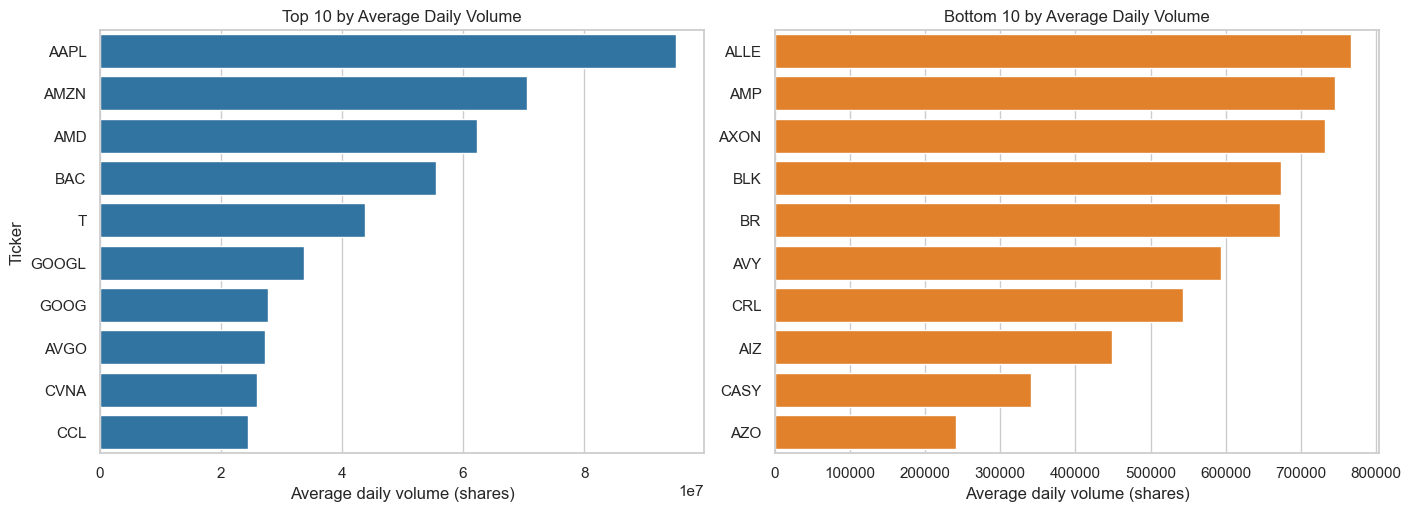

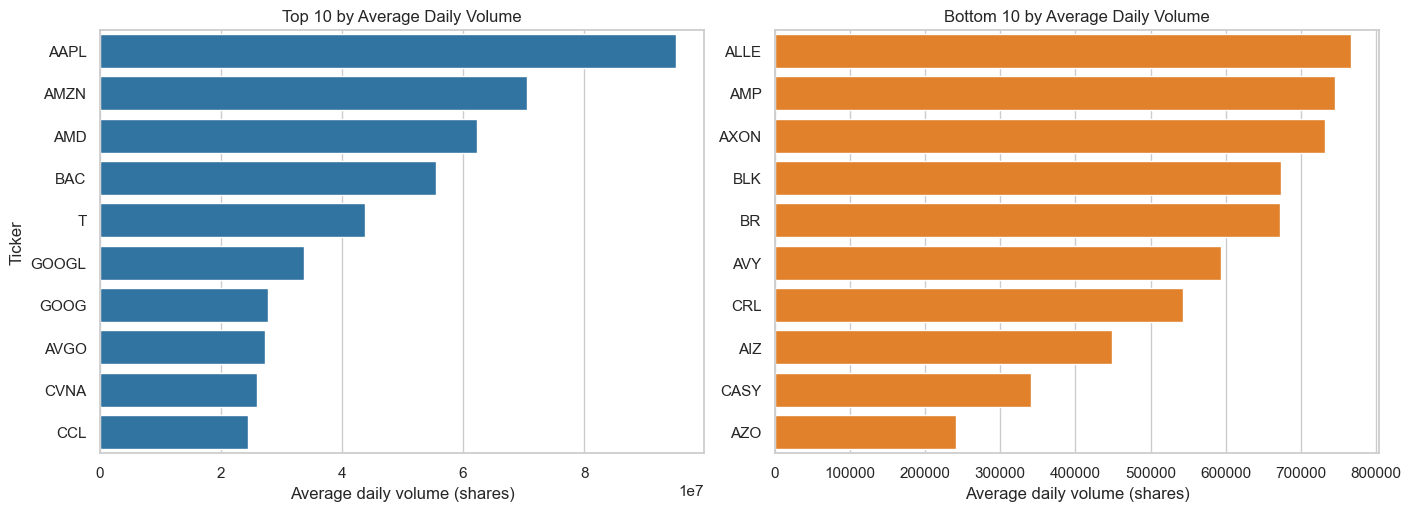

In [ ]:
avg_volume = average_daily_volume(raw)
volume_rank = pd.concat(
    {
        "top_10": avg_volume.head(10),
        "bottom_10": avg_volume.tail(10).sort_values(ascending=False),
    }
).rename("average_daily_volume").reset_index()
volume_rank.columns = ["rank_group", "ticker", "average_daily_volume"]

display(volume_rank)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
sns.barplot(
    data=volume_rank.loc[volume_rank["rank_group"] == "top_10"],
    x="average_daily_volume",
    y="ticker",
    color="#1f77b4",
    ax=axes[0],
)
axes[0].set_title("Top 10 by Average Daily Volume")
axes[0].set_xlabel("Average daily volume (shares)")
axes[0].set_ylabel("Ticker")

sns.barplot(
    data=volume_rank.loc[volume_rank["rank_group"] == "bottom_10"],
    x="average_daily_volume",
    y="ticker",
    color="#ff7f0e",
    ax=axes[1],
)
axes[1].set_title("Bottom 10 by Average Daily Volume")
axes[1].set_xlabel("Average daily volume (shares)")
axes[1].set_ylabel("")
fig

## 3. Task 3 — Data quality checks and documented cleaning

### Cleaning policy

`clean_ohlcv()` applies the following rules:

1. Standardize the schema and require `date`, `ticker`, `open`, `high`, `low`, `close`, `volume`, and `adj_close`.
2. Drop rows without a usable date or ticker.
3. Keep the last duplicate observation for a duplicate date/ticker pair.
4. Drop rows with nonpositive adjusted close because returns are undefined.
5. Convert negative volume to missing rather than inventing volume.
6. Forward-fill only isolated missing adjusted-close values within each ticker, for at most 3 observations.
7. Never forward-fill before a ticker's first observed price; this avoids fabricating pre-IPO history.
8. Drop adjusted-close rows that remain missing after the limited fill.
9. Do not interpolate OHLC values.
10. Flag return outliers and volume spikes instead of silently deleting them.
11. Use Yahoo Finance adjusted close for split/dividend adjustment.

This is deliberately conservative: `ffill` is appropriate for isolated missing adjusted prices because it carries forward the last observable market price, but interpolation can create artificial prices and artificial return smoothness. Dropping all missing rows would remove otherwise valid ticker history, so it is reserved for adjusted-close observations that cannot be responsibly filled.

In [ ]:
cleaned, quality_report = clean_ohlcv(raw)

cleaning_summary = pd.Series(
    {
        "input_rows": quality_report["input_rows"],
        "invalid_date_rows_removed": quality_report["invalid_date_rows_removed"],
        "blank_ticker_rows_removed": quality_report["blank_ticker_rows_removed"],
        "duplicate_rows_removed": quality_report["duplicate_rows_removed"],
        "nonpositive_adj_close_rows_removed": quality_report[
            "nonpositive_adj_close_rows_removed"
        ],
        "negative_volume_rows_set_to_missing": quality_report[
            "negative_volume_rows_set_to_missing"
        ],
        "adj_close_missing_before_fill": quality_report[
            "adj_close_missing_before_fill"
        ],
        "adj_close_values_forward_filled": quality_report[
            "adj_close_values_forward_filled"
        ],
        "rows_removed_with_unfilled_adj_close": quality_report[
            "rows_removed_with_unfilled_adj_close"
        ],
        "output_rows": quality_report["output_rows"],
    },
    name="rows",
).to_frame()

display(cleaning_summary)
print(quality_report["survivorship_bias_note"])

,rows
input_rows,247816
invalid_date_rows_removed,0
blank_ticker_rows_removed,0
duplicate_rows_removed,0
nonpositive_adj_close_rows_removed,0
negative_volume_rows_set_to_missing,0
adj_close_missing_before_fill,0
adj_close_values_forward_filled,0
rows_removed_with_unfilled_adj_close,0
output_rows,247816


The universe is a current S&P 500 constituent snapshot; delisted stocks and historical index changes are not represented.


### Missing values by year

The quality report separates adjusted-price missingness from volume missingness and also reports the percentage of missing cells across all numeric OHLCV fields.

In [ ]:
missing_year = pd.DataFrame(quality_report["missing_by_year"])
missing_year

,year,rows,adj_close_missing,adj_close_missing_pct,volume_missing,volume_missing_pct,all_ohlcv_missing_pct
0,2016,10272,0,0.0,0,0.0,0.0
1,2017,24267,0,0.0,0,0.0,0.0
2,2018,24347,0,0.0,0,0.0,0.0
3,2019,24444,0,0.0,0,0.0,0.0
4,2020,24756,0,0.0,0,0.0,0.0
5,2021,25130,0,0.0,0,0.0,0.0
6,2022,25100,0,0.0,0,0.0,0.0
7,2023,25000,0,0.0,0,0.0,0.0
8,2024,25200,0,0.0,0,0.0,0.0
9,2025,25000,0,0.0,0,0.0,0.0


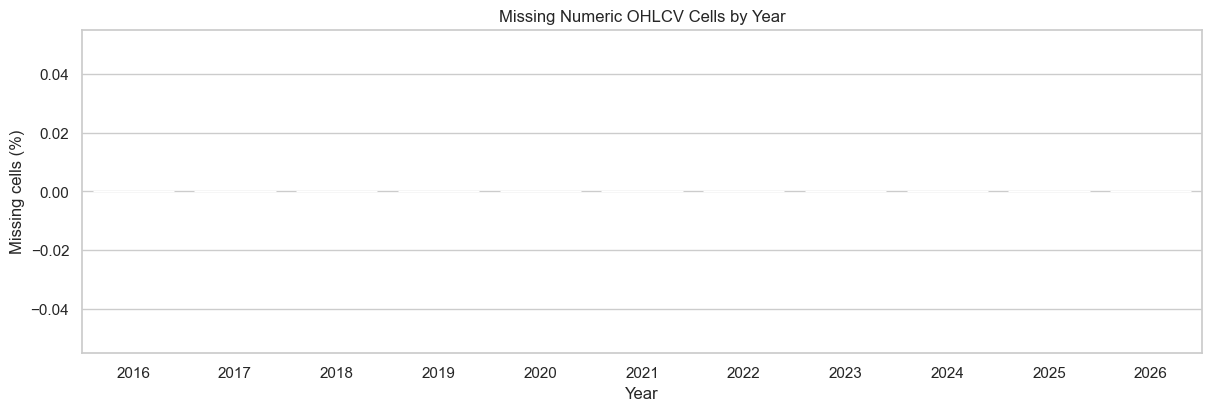

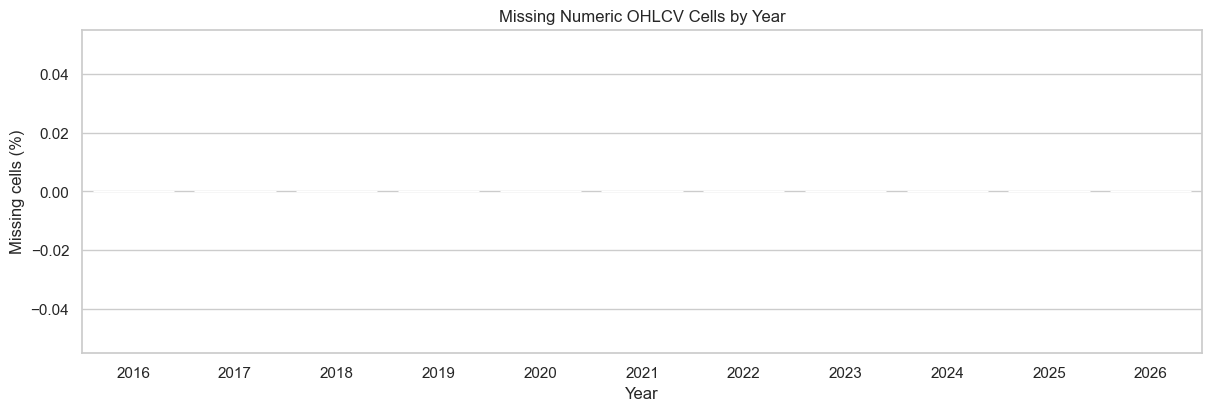

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4), constrained_layout=True)
sns.barplot(data=missing_year, x="year", y="all_ohlcv_missing_pct", color="#4c78a8", ax=ax)
ax.set_title("Missing Numeric OHLCV Cells by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Missing cells (%)")
fig

### Suspicious return outliers and volume spikes

Return outliers are daily simple returns with absolute value greater than 50%. Volume spikes are observations above 10× the prior rolling 60-day median volume. These events are **flags**, not automatic deletions: they can reflect real crashes, halts, corporate actions, or genuine high-volume trading days.

In [ ]:
return_outlier_report = quality_report["suspicious_return_outliers"]
volume_spike_report = quality_report["suspicious_volume_spikes"]

print(f"Daily return outliers > ±50%: {return_outlier_report['count']}")
print("Suspicious return-outlier tickers:", return_outlier_report["tickers"])
print(f"Volume spikes > 10× prior 60-day median: {volume_spike_report['count']}")
print("Suspicious volume-spike tickers:", volume_spike_report["tickers"])

return_outliers = pd.DataFrame(return_outlier_report["top_events"])
volume_spikes = pd.DataFrame(volume_spike_report["top_events"])

display(return_outliers)
display(volume_spikes)

Daily return outliers > ±50%: 2
Suspicious return-outlier tickers: ['APA', 'CVNA']
Volume spikes > 10× prior 60-day median: 198
Suspicious volume-spike tickers: ['ABBV', 'ABNB', 'ACGL', 'ADBE', 'ADM', 'ADP', 'ADSK', 'AIZ', 'AJG', 'AKAM', 'ALGN', 'AMCR', 'ANET', 'AOS', 'APA', 'APO', 'APP', 'ARE', 'ARES', 'ATO', 'AVGO', 'AXON', 'BA', 'BAX', 'BBY', 'BDX', 'BF-B', 'BG', 'BIIB', 'BKR', 'BLDR', 'BLK', 'BMY', 'BR', 'BRO', 'BX', 'BXP', 'CASY', 'CBOE', 'CCL', 'CDNS', 'CDW', 'CHRW', 'CHTR', 'CNC', 'CNP', 'CPT', 'CRL', 'CVNA', 'MMM', 'MO', 'SCHW', 'TECH', 'XYZ']


,date,ticker,simple_return
0,2023-06-08,CVNA,0.560206
1,2020-03-09,APA,-0.538647


,date,ticker,volume,median_volume,volume_ratio
0,2019-06-26,AMCR,1871220.0,10.0,187122.000000
1,2019-06-27,AMCR,1083860.0,10.0,108386.000000
2,2019-07-01,AMCR,1559840.0,20.0,77992.000000
3,2019-06-28,AMCR,1520900.0,20.0,76045.000000
4,2019-07-09,AMCR,1339820.0,20.0,66991.000000
5,2019-07-02,AMCR,1321740.0,20.0,66087.000000
6,2019-07-10,AMCR,728480.0,20.0,36424.000000
7,2019-07-05,AMCR,713020.0,20.0,35651.000000
8,2019-07-08,AMCR,606200.0,20.0,30310.000000
9,2019-07-03,AMCR,602700.0,20.0,30135.000000


### Survivorship-bias check

The dataset uses the current S&P 500 constituent list. Stocks that were removed from the index during the 10-year window are absent, while newer constituents such as APP, ABNB, CARR, and CVNA have shorter histories. This means the portfolio results are a research exercise on a surviving/current universe, not a point-in-time investable S&P 500 backtest.

## 4. Task 4 — Simple/log returns and frequency aggregation

- **Simple return:** `R_t = P_t / P_{t-1} - 1`. Use simple returns for cross-sectional portfolio aggregation because a portfolio return is the weighted sum of asset simple returns.
- **Log return:** `r_t = ln(P_t / P_{t-1})`. Log returns are additive through time and are useful for time aggregation and statistical modeling.
- Weekly returns use Friday-ending intervals; monthly returns use month-end intervals. Both use the last available adjusted price in each interval, so simple returns compound correctly.

In [ ]:
prices = pivot_ohlcv(cleaned, "adj_close")
daily_simple = compute_returns(prices, method="simple", frequency="D")
daily_log = compute_returns(prices, method="log", frequency="D")
weekly_simple = compute_returns(prices, method="simple", frequency="W")
monthly_simple = compute_returns(prices, method="simple", frequency="M")

returns_overview = pd.DataFrame(
    {
        "frequency": ["daily simple", "daily log", "weekly simple", "monthly simple"],
        "rows": [
            len(daily_simple),
            len(daily_log),
            len(weekly_simple),
            len(monthly_simple),
        ],
        "columns": [
            daily_simple.shape[1],
            daily_log.shape[1],
            weekly_simple.shape[1],
            monthly_simple.shape[1],
        ],
        "non_missing_values": [
            int(daily_simple.count().sum()),
            int(daily_log.count().sum()),
            int(weekly_simple.count().sum()),
            int(monthly_simple.count().sum()),
        ],
    }
)
returns_overview

,frequency,rows,columns,non_missing_values
0,daily simple,2512,100,247716
1,daily log,2512,100,247716
2,weekly simple,522,100,51401
3,monthly simple,120,100,11741


### Manual spot checks

These checks compare the vectorized implementation with direct formulas for one daily simple return, one daily log return, and one monthly simple return.

In [ ]:
sample_ticker = "AAPL" if "AAPL" in prices.columns else prices.columns[0]
sample_date = daily_simple[sample_ticker].dropna().index[0]
previous_price = prices[sample_ticker].shift(1).loc[sample_date]
current_price = prices.loc[sample_date, sample_ticker]

monthly_prices = prices.resample("ME").last()
monthly_sample_date = monthly_simple[sample_ticker].dropna().index[0]
manual_monthly = (
    monthly_prices.loc[monthly_sample_date, sample_ticker]
    / monthly_prices[sample_ticker].shift(1).loc[monthly_sample_date]
    - 1
)

spot_checks = pd.DataFrame(
    {
        "calculation": [
            f"daily simple {sample_ticker} {sample_date.date()}",
            f"daily log {sample_ticker} {sample_date.date()}",
            f"monthly simple {sample_ticker} {monthly_sample_date.date()}",
        ],
        "function_value": [
            daily_simple.loc[sample_date, sample_ticker],
            daily_log.loc[sample_date, sample_ticker],
            monthly_simple.loc[monthly_sample_date, sample_ticker],
        ],
        "manual_value": [
            current_price / previous_price - 1,
            np.log(current_price / previous_price),
            manual_monthly,
        ],
    }
)
spot_checks["absolute_difference"] = (
    spot_checks["function_value"] - spot_checks["manual_value"]
).abs()
spot_checks

,calculation,function_value,manual_value,absolute_difference
0,daily simple AAPL 2016-08-02,-0.014804,-0.014804,0.0
1,daily log AAPL 2016-08-02,-0.014915,-0.014915,0.0
2,monthly simple AAPL 2016-09-30,0.065504,0.065504,0.0


### Return distributions for five stocks

The five stocks below are chosen as liquid, representative names when available. The table reports skewness and excess kurtosis; a normal distribution has values near 0 for both.

,mean,std,skewness,excess_kurtosis
ticker,,,,
AAPL,0.001219,0.018287,0.146965,6.857570
AMZN,0.000918,0.020562,0.171848,5.034846
AMD,0.002299,0.035828,0.353516,4.566453
BAC,0.000850,0.019197,0.243454,11.155588
T,0.000269,0.015123,-0.250293,6.783886


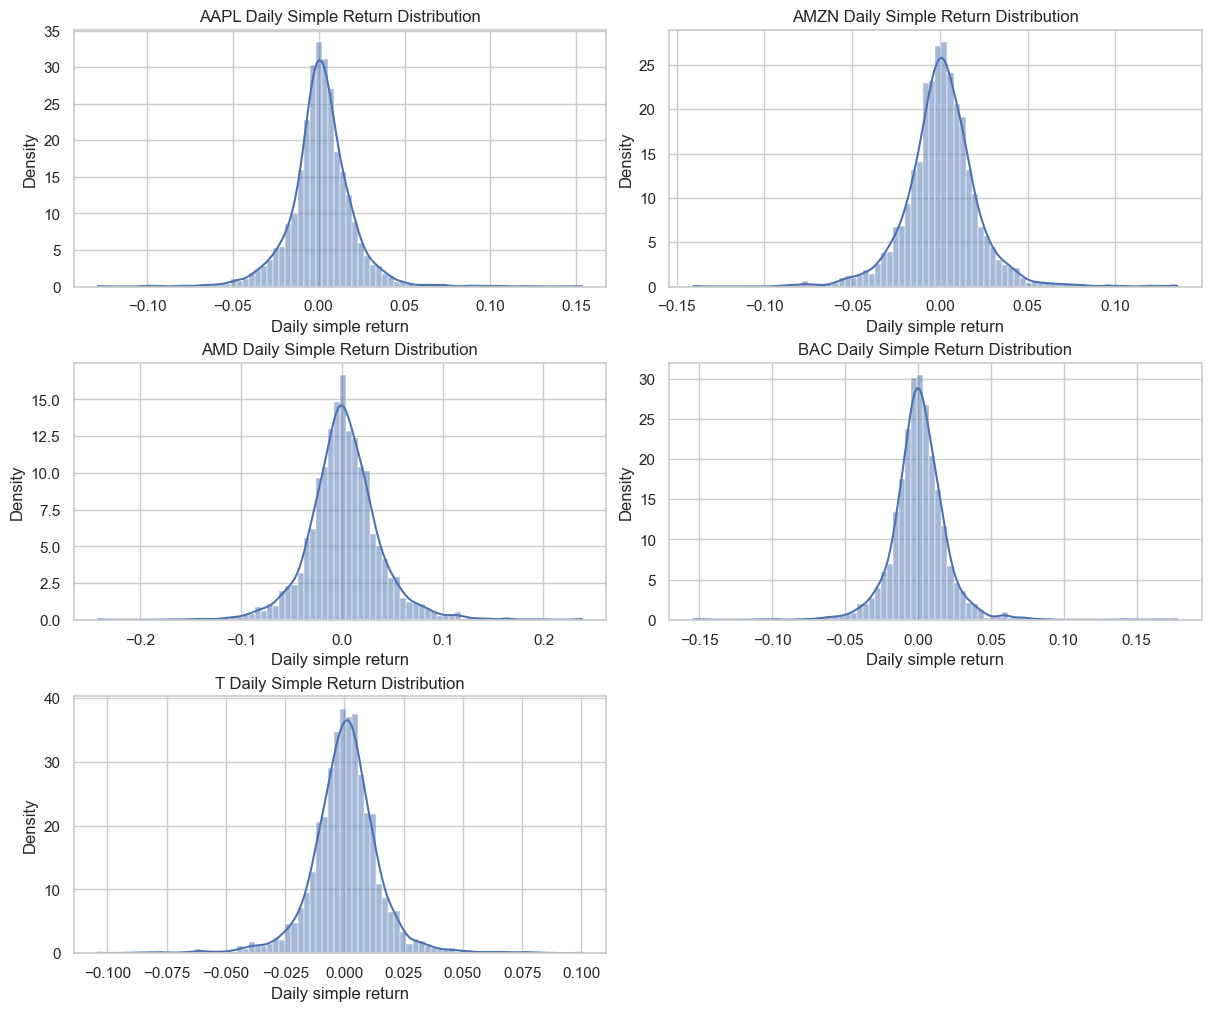

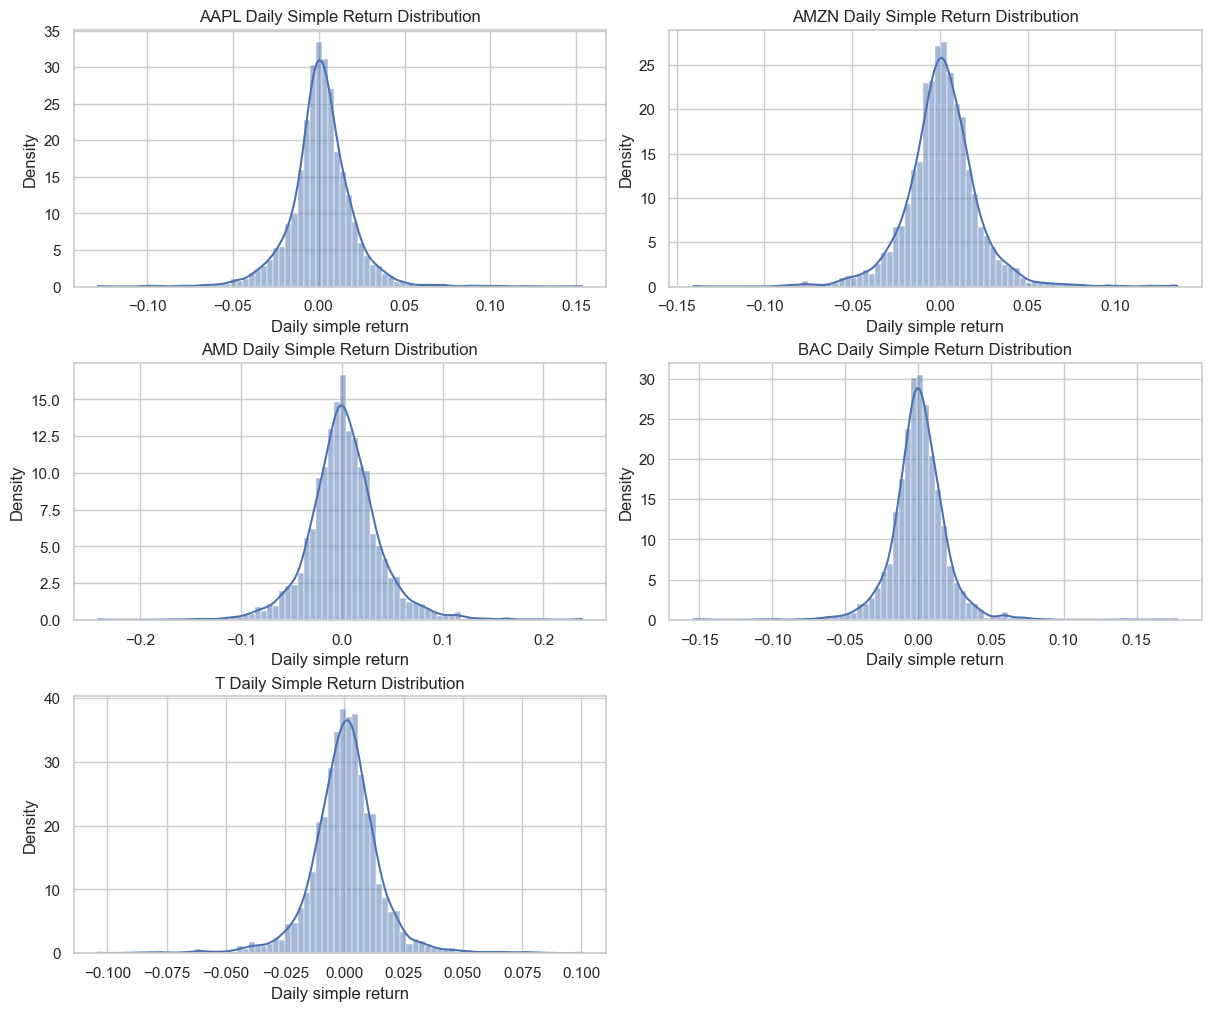

In [ ]:
preferred = ["AAPL", "MSFT", "JPM", "XOM", "JNJ"]
selected_tickers = [ticker for ticker in preferred if ticker in daily_simple.columns]
if len(selected_tickers) < 5:
    for ticker in avg_volume.index:
        if ticker in daily_simple.columns and ticker not in selected_tickers:
            selected_tickers.append(ticker)
        if len(selected_tickers) == 5:
            break

distribution_stats = pd.DataFrame(
    {
        "mean": daily_simple[selected_tickers].mean(),
        "std": daily_simple[selected_tickers].std(),
        "skewness": stats.skew(
            daily_simple[selected_tickers], axis=0, nan_policy="omit"
        ),
        "excess_kurtosis": stats.kurtosis(
            daily_simple[selected_tickers], axis=0, nan_policy="omit"
        ),
    }
)
distribution_stats.index.name = "ticker"
display(distribution_stats.round(6))

fig, axes = plt.subplots(3, 2, figsize=(12, 10), constrained_layout=True)
for ax, ticker in zip(axes.flat, selected_tickers, strict=False):
    sns.histplot(
        daily_simple[ticker].dropna(),
        bins=80,
        kde=True,
        stat="density",
        ax=ax,
    )
    ax.set_title(f"{ticker} Daily Simple Return Distribution")
    ax.set_xlabel("Daily simple return")
axes.flat[len(selected_tickers)].set_visible(False)
fig

### Daily vs. monthly volatility and the square-root-of-time rule

Under independent, identically distributed returns, volatility scales by `sqrt(T)`. With approximately 21 trading days per month, monthly volatility should be roughly `sqrt(21) ≈ 4.58` times daily volatility. Real equity returns have autocorrelation, volatility clustering, and fat tails, so the ratio is approximate rather than exact.

Median monthly/daily volatility ratio: 4.198
Square-root approximation, sqrt(21): 4.583


,daily_volatility,monthly_volatility,monthly_to_daily_ratio
ticker,,,
AAPL,0.018287,0.079710,4.358941
AMZN,0.020562,0.089661,4.360600
AMD,0.035828,0.180915,5.049588
BAC,0.019197,0.082578,4.301664
T,0.015123,0.065656,4.341398


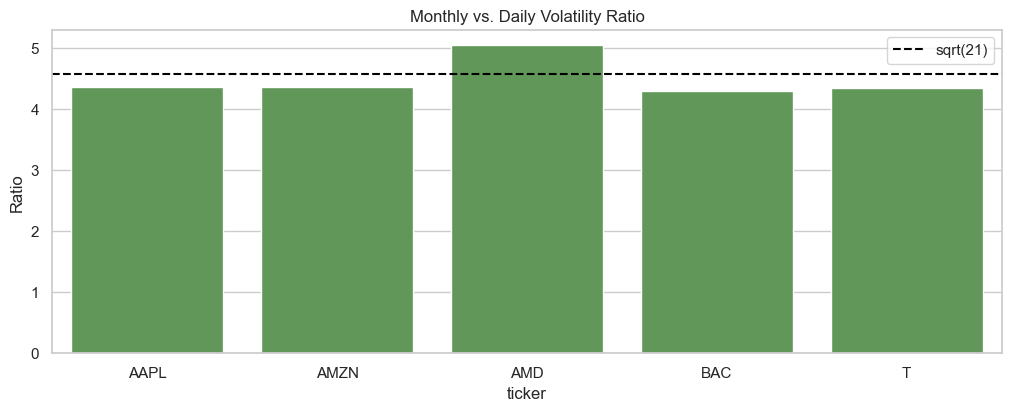

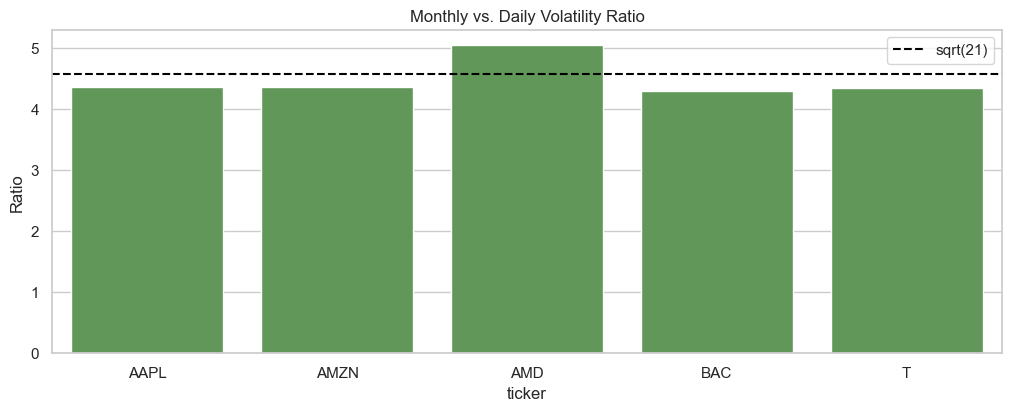

In [ ]:
daily_vol = daily_simple.std()
monthly_vol = monthly_simple.std()
vol_ratio = monthly_vol / daily_vol

volatility_comparison = pd.DataFrame(
    {
        "daily_volatility": daily_vol,
        "monthly_volatility": monthly_vol,
        "monthly_to_daily_ratio": vol_ratio,
    }
).loc[selected_tickers]

print(f"Median monthly/daily volatility ratio: {vol_ratio.median():.3f}")
print(f"Square-root approximation, sqrt(21): {np.sqrt(21):.3f}")
display(volatility_comparison.round(6))

fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)
sns.barplot(
    data=volatility_comparison.reset_index(),
    x="ticker",
    y="monthly_to_daily_ratio",
    color="#59a14f",
    ax=ax,
)
ax.axhline(np.sqrt(21), color="black", linestyle="--", label="sqrt(21)")
ax.set_title("Monthly vs. Daily Volatility Ratio")
ax.set_ylabel("Ratio")
ax.legend()
fig

## 5. Task 5 — Rolling statistics and portfolio returns

Because the dataset contains individual stocks but not a separate SPY file, the market proxy is the daily equal-weight mean return of the 100-stock cleaned universe. Rolling means and standard deviations use 20-, 60-, and 252-day windows.

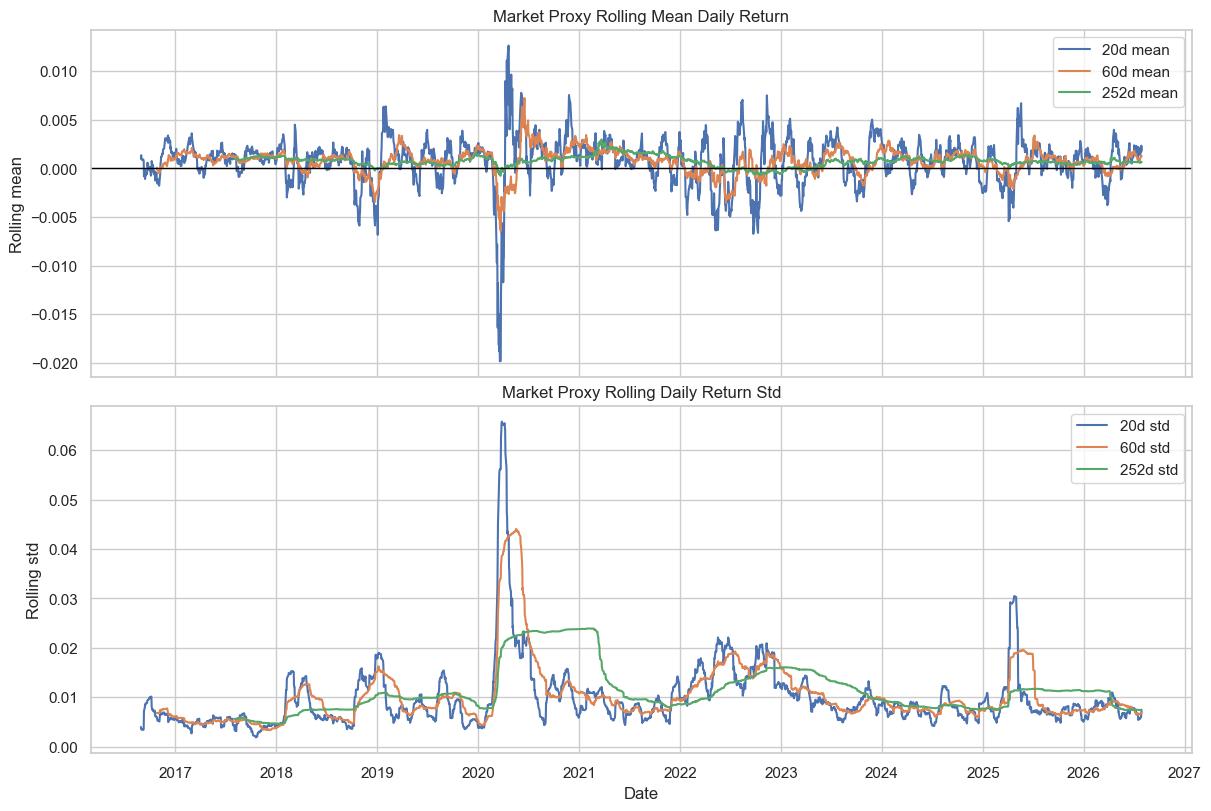

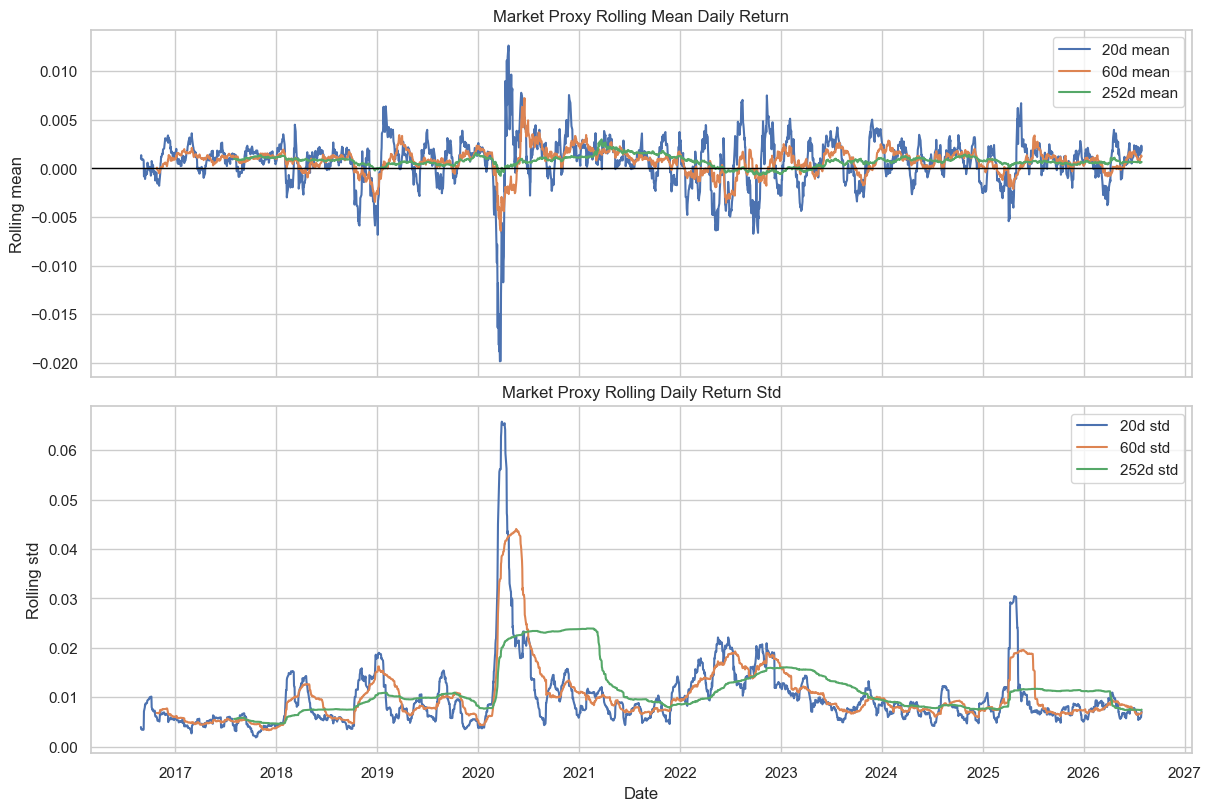

In [ ]:
market_proxy = portfolio_returns(daily_simple).rename("market_proxy")
market_rolling = compute_rolling_stats(
    market_proxy.to_frame(), windows=(20, 60, 252)
)

rolling_plot_data = pd.DataFrame(
    {
        f"{window}d mean": market_rolling[window][("mean", "market_proxy")]
        for window in (20, 60, 252)
    }
)
rolling_std_data = pd.DataFrame(
    {
        f"{window}d std": market_rolling[window][("std", "market_proxy")]
        for window in (20, 60, 252)
    }
)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True, constrained_layout=True)
sns.lineplot(data=rolling_plot_data, dashes=False, ax=axes[0])
axes[0].set_title("Market Proxy Rolling Mean Daily Return")
axes[0].set_ylabel("Rolling mean")
axes[0].axhline(0, color="black", linewidth=1)

sns.lineplot(data=rolling_std_data, dashes=False, ax=axes[1])
axes[1].set_title("Market Proxy Rolling Daily Return Std")
axes[1].set_ylabel("Rolling std")
axes[1].set_xlabel("Date")
fig

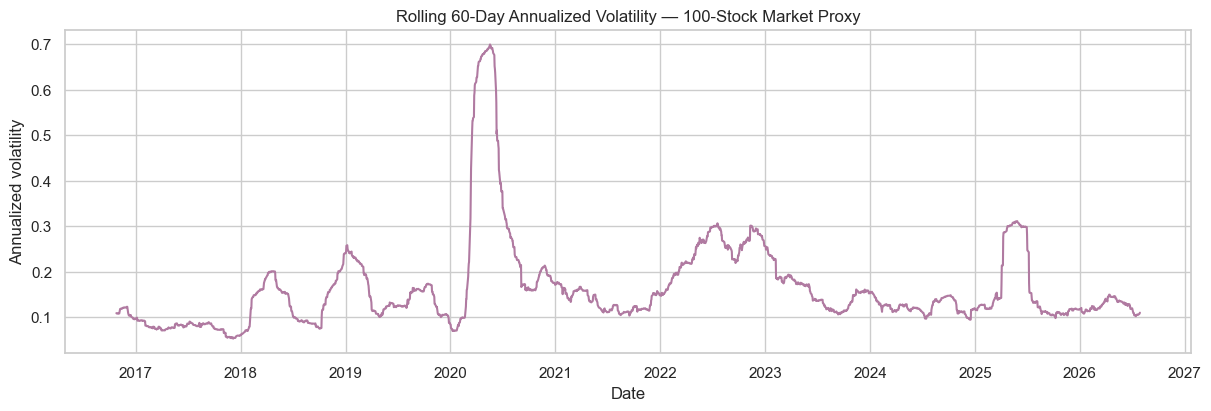

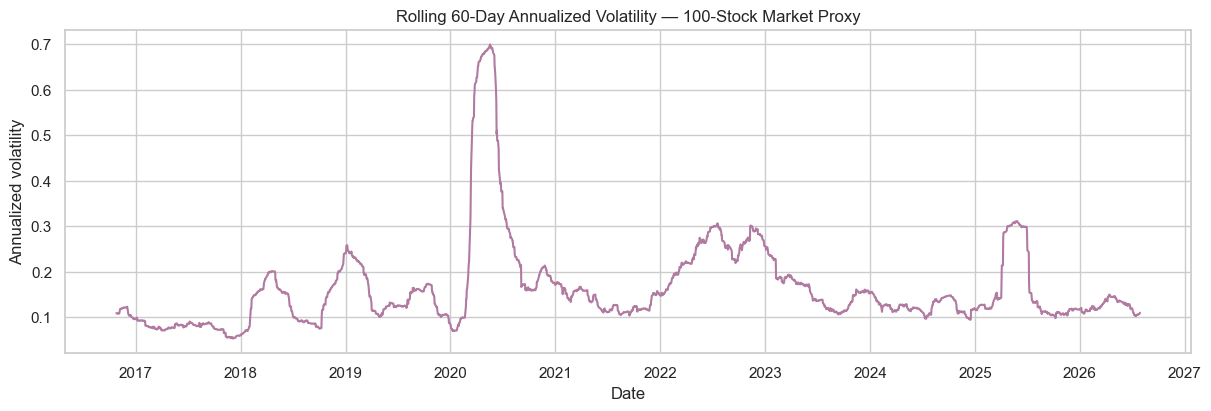

In [ ]:
rolling_60d_annualized_vol = (
    market_rolling[60][("std", "market_proxy")] * np.sqrt(252)
)

fig, ax = plt.subplots(figsize=(12, 4), constrained_layout=True)
sns.lineplot(
    x=rolling_60d_annualized_vol.index,
    y=rolling_60d_annualized_vol.values,
    color="#b07aa1",
    ax=ax,
)
ax.set_title("Rolling 60-Day Annualized Volatility — 100-Stock Market Proxy")
ax.set_xlabel("Date")
ax.set_ylabel("Annualized volatility")
fig

### 50-stock portfolio construction

To avoid look-ahead bias in portfolio selection:

1. The **first 252 trading days** are used only as a formation window.
2. Average dollar volume is `adj_close × volume` during that formation window.
3. The 50 eligible stocks with the highest formation-period average dollar volume are selected.
4. Value weights are proportional to formation-period average dollar volume. This is a liquidity-value proxy, not true market-cap weighting.
5. Portfolio evaluation starts **after** the formation window.

Equal-weight returns are the daily cross-sectional mean of the same 50 stocks. Both portfolios use daily simple returns.

In [ ]:
formation_dates = prices.index[:252]
formation_end = formation_dates[-1]
formation_prices = prices.loc[formation_dates]
formation_volume = pivot_ohlcv(cleaned, "volume").reindex(formation_dates)
formation_dollar_volume = formation_prices * formation_volume

eligible_counts = formation_prices.notna().sum()
eligible = eligible_counts.loc[eligible_counts >= 200].index
average_dollar_volume = formation_dollar_volume[eligible].mean().sort_values(
    ascending=False
)
portfolio_tickers = average_dollar_volume.head(50).index
value_weights = average_dollar_volume.loc[portfolio_tickers]
value_weights = value_weights / value_weights.sum()

evaluation_returns = daily_simple.loc[
    daily_simple.index > formation_end, list(portfolio_tickers)
]
equal_weight_portfolio = portfolio_returns(evaluation_returns).rename(
    "Equal-weight 50"
)
value_weight_portfolio = portfolio_returns(
    evaluation_returns, value_weights
).rename("Value-weight proxy 50")
portfolio_daily = pd.concat(
    [equal_weight_portfolio, value_weight_portfolio], axis=1
).dropna()

portfolio_summary = pd.Series(
    {
        "formation_window_start": formation_dates[0].date(),
        "formation_window_end": formation_end.date(),
        "evaluation_start": portfolio_daily.index[0].date(),
        "evaluation_end": portfolio_daily.index[-1].date(),
        "portfolio_stock_count": len(portfolio_tickers),
        "evaluation_days": len(portfolio_daily),
    }
)
display(portfolio_summary.to_frame("value"))
display(value_weights.sort_values(ascending=False).head(10).to_frame("weight"))

,value
formation_window_start,2016-08-01
formation_window_end,2017-07-31
evaluation_start,2017-08-01
evaluation_end,2026-07-29
portfolio_stock_count,50
evaluation_days,2260


,weight
ticker,
AAPL,0.149144
AMZN,0.133529
BAC,0.069223
GOOGL,0.062438
GOOG,0.056166
BKNG,0.030852
AMD,0.029976
BRK-B,0.024186
CHTR,0.023334


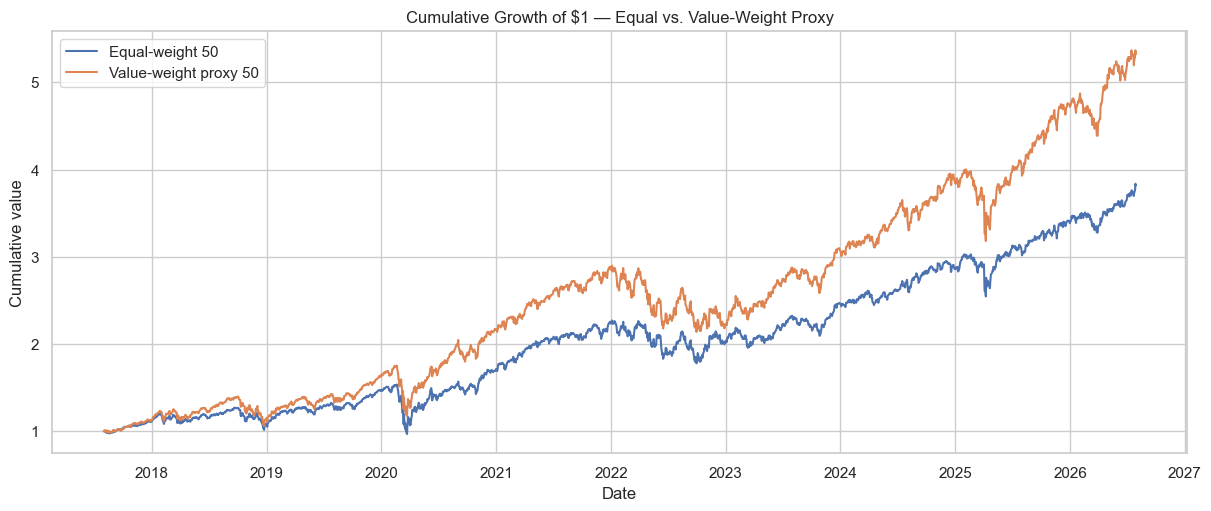

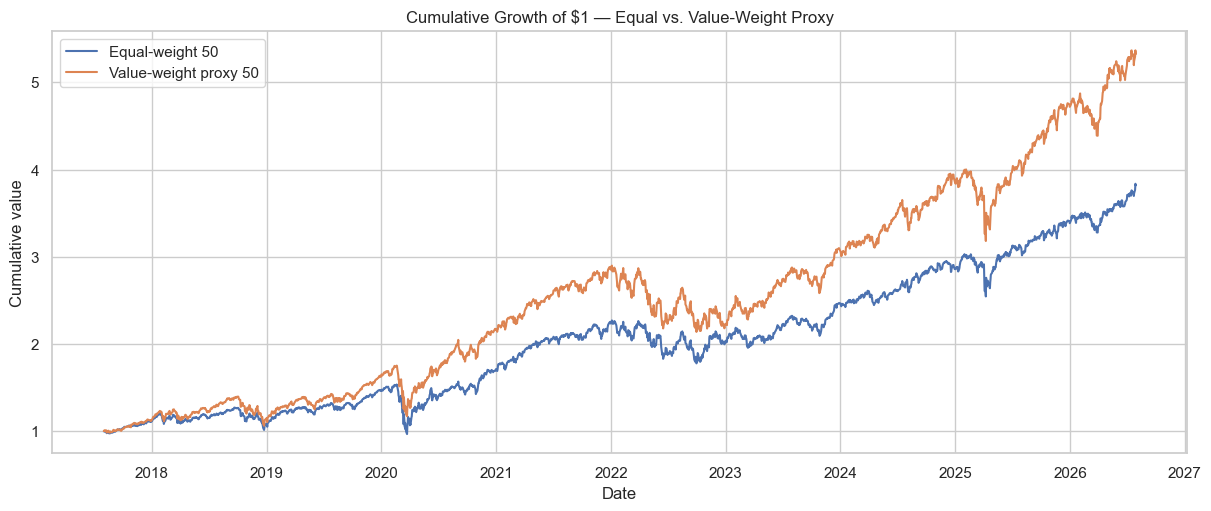

In [ ]:
portfolio_cumulative = portfolio_daily.apply(cumulative_returns)

fig, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)
sns.lineplot(data=portfolio_cumulative, dashes=False, ax=ax)
ax.set_title("Cumulative Growth of $1 — Equal vs. Value-Weight Proxy")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative value")
fig

In [ ]:
performance = pd.DataFrame(
    {
        column: portfolio_performance(
            portfolio_daily[column], periods_per_year=252, risk_free_rate=0.0
        )
        for column in portfolio_daily.columns
    }
).T

performance_display = performance.copy()
performance_display["annualized_return"] = performance_display[
    "annualized_return"
].map("{:.2%}".format)
performance_display["annualized_volatility"] = performance_display[
    "annualized_volatility"
].map("{:.2%}".format)
performance_display["sharpe_ratio"] = performance_display["sharpe_ratio"].map(
    "{:.3f}".format
)
performance_display["periods"] = performance_display["periods"].astype(int)
performance_display

,annualized_return,annualized_volatility,sharpe_ratio,periods
Equal-weight 50,16.11%,19.46%,0.828,2260
Value-weight proxy 50,20.49%,21.20%,0.967,2260


## 6. Final quality checks and conclusions

The final checks verify that the cleaned dataset still covers 100 tickers, contains no duplicate date/ticker rows, and has complete adjusted-close observations after cleaning.

In [ ]:
final_validation = validate_ohlcv(cleaned)

assert final_validation["schema_valid"]
assert final_validation["ticker_count"] == 100
assert final_validation["duplicate_date_ticker_rows"] == 0
assert final_validation["missing_by_column"]["adj_close"] == 0
assert spot_checks["absolute_difference"].max() < 1e-12

print("Final cleaned rows:", f"{len(cleaned):,}")
print("Final ticker count:", final_validation["ticker_count"])
print("Duplicate date/ticker rows:", final_validation["duplicate_date_ticker_rows"])
print("Missing adjusted close:", final_validation["missing_by_column"]["adj_close"])
print("Week 1 quality checks completed successfully.")

Final cleaned rows: 247,816
Final ticker count: 100
Duplicate date/ticker rows: 0
Missing adjusted close: 0
Week 1 quality checks completed successfully.
